<h1>23 - Features séléection avec Scikit-Learn</h1>

Lien Vidéo tuto: <a href="https://www.youtube.com/watch?v=T4nZDuakYlU&list=PLO_fdPEVlfKqMDNmCFzQISI2H_nJcEDJq&index=29">EATURE SELECTION avec SKLEARN (23/30)</a> (durée : 26 min)

On va voir ici comment faire de la sélection de variables avec Scikit-Learn. Cette technique consiste à trouver puis sélectionner les variables les plus utiles pour l'entrainement d'un modèle, parmis toutes les variables disponible dans un dataset. Il s'agit une des opération les plus importante à réaliser lors du pre-processing, car quand on fournit trop de variables à un modèle, notamment des variables qui ne sont pas utiles au modèle. Eh bien cela affecte sa performance de manière négative. 

On va voir ici plusieurs techniques afin de sélectionner les variables les plus importantes.

Commençons par observer le contenu du module `Feature Selection` de Scikit-Learn. Dans ce module on va notamment retrouver des transformers, ainsiq que des tests de dépendances (fonctions) :

<u>Transformers</u>:

- GenericUnivariateSelect : basé sur un test statistique
- SelectPercentile : basé sur un test statistique
- SelectKBest : basé sur un test statistique
- SelectFpr : basé sur un test statistique
- SelectFdr : basé sur un test statistique
- SelectFromModel : estimateur de coefficients
- SelectFwe : basé sur un test statistique
- RFE : estimateur de coefficients
- RFECV : estimateur de coefficients
- VarianceThreshold : basé sur la variance

<u>Tests de dépendance</u>:

- chi2 : test de dépendances pour faire de la classificaiton
- f_classif :  test de dépendances pour faire de la classificaiton
- f_regression : test pour faire de la regression (Pearson, ...)
- mutual_info_classif :  test de dépendances pour faire de la classificaiton
- mutual_info_regression : test pour faire de la regression (Pearson, ...)


Dans ce lot d'algorithmes, nous allons explorer dans ce tuto les modèles suivants: 
- Variance Threshold : selectionne les variables (features) selon leur degrés de variation. C'est-à-dire, selon leur variance.
- SelectKBest : selectionne nos variables à partir de tests statistiques (chi2, ANOVA, ). On parle de tests de dépendances. `SelectKBest` et `SelectPercentil` sont intéressant, tendis que les autres de la même famille sont dans le même esprit mais pas forcément intéressants.  
- SelectFromModel : utilise les coefficient d'un modèle pré-entrainé sur tout le dataset
- La matrice coefficients
- RFE + REFCV : réalisent une sélection récursive de nos variables ( à partir de coéfficients ?)


<h2>Setup</h2>

In [10]:
# Standard libraries
import numpy as np

# Data loading methods
from sklearn.datasets import load_iris

# Visualization dataset
import matplotlib.pyplot as plt

# ML libraries
from sklearn.feature_selection import VarianceThreshold

<h2>Variance Threshold</h2>

Cet algorithme va calculer les variances de toutes les variables de notre dataset, puis élimine les variables dont la variance est inférieure au seuil que nous définissons. Le but de cette opération est de supprimer les variables qui ne varient que très peu, voire pas du tout. En effet, à quoi cela sert d'avoir une variable si elle ne varie pas ou si c'est une constante. 

Par exemple, si on avait un tableau qui liste des surface des appartement de la ville de Paris, avec leur prix, et qu'on avait une colonne `Ville` (donc une variable/Feature "Ville") dont la seule valeur était "Paris" à toutes les lignes, alors on ne présenterait pas cette variable au modèle. En effet, cette variable n'apporte pas plus d'information si on entraine le modèle uniquement pour des individus de Paris. Rajouter cette variable lors de l'entrainement serait inutile, et pourrait voire même dégrader les performances du modèle si on lui fournissait un appartement venant d'une autre ville. Avec un changement de valeur dans la colonne ville, le modèle ne saurait pas comment interpréter ce changement.

-> <span style="color:rgb(249, 116, 50)">Pour réaliser des prédictions, un estimateur doit avoir besoin d'informations qui varient en accord avec la target. </span>

Illustrons cet algorithme en utilisant le dataset des fleurs d'Iris. 


In [3]:
# Load itis dataset
iris = load_iris()

# Extract features and target
X = iris.data
y = iris.target

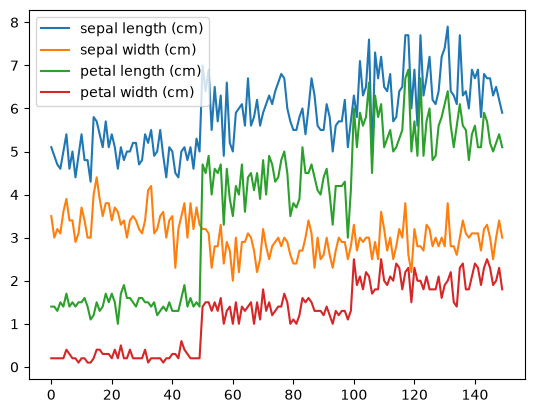

In [5]:
# Display features
plt.plot(X)
plt.legend(iris.feature_names)

Ici, on peut voir qu'en affichant nos différentes variable, certaines d'entre elles varient pas mal, comme `petal length` (comprise dans [1, 6]), et d'autres variables varient beaucoup moins comme `sepal width` (comprise dans [3,4]).  


Ce qu'on pourrait faire c'est d'utiliser l'algorithme `VarianceThreshold` afin d'éliminer la variable `sepal width`, si toutefois elle est inférieure au seuil de variance qu'on aura défini.

In [ ]:
# Compute the variance for each of ours signals (features/variables)
X.var(axis=0)

array([0.68112222, 0.18871289, 3.09550267, 0.57713289])

In [7]:
# Instantiate the algorithme
selector = VarianceThreshold(threshold=0.2)

# Adjust/Fit the model to our data
selector.fit_transform(X)

array([[5.1, 1.4, 0.2],
       [4.9, 1.4, 0.2],
       [4.7, 1.3, 0.2],
       [4.6, 1.5, 0.2],
       [5. , 1.4, 0.2],
       [5.4, 1.7, 0.4],
       [4.6, 1.4, 0.3],
       [5. , 1.5, 0.2],
       [4.4, 1.4, 0.2],
       [4.9, 1.5, 0.1],
       [5.4, 1.5, 0.2],
       [4.8, 1.6, 0.2],
       [4.8, 1.4, 0.1],
       [4.3, 1.1, 0.1],
       [5.8, 1.2, 0.2],
       [5.7, 1.5, 0.4],
       [5.4, 1.3, 0.4],
       [5.1, 1.4, 0.3],
       [5.7, 1.7, 0.3],
       [5.1, 1.5, 0.3],
       [5.4, 1.7, 0.2],
       [5.1, 1.5, 0.4],
       [4.6, 1. , 0.2],
       [5.1, 1.7, 0.5],
       [4.8, 1.9, 0.2],
       [5. , 1.6, 0.2],
       [5. , 1.6, 0.4],
       [5.2, 1.5, 0.2],
       [5.2, 1.4, 0.2],
       [4.7, 1.6, 0.2],
       [4.8, 1.6, 0.2],
       [5.4, 1.5, 0.4],
       [5.2, 1.5, 0.1],
       [5.5, 1.4, 0.2],
       [4.9, 1.5, 0.2],
       [5. , 1.2, 0.2],
       [5.5, 1.3, 0.2],
       [4.9, 1.4, 0.1],
       [4.4, 1.3, 0.2],
       [5.1, 1.5, 0.2],
       [5. , 1.3, 0.3],
       [4.5, 1.3

On observe qu'une colonne a été supprimée. Certes ce n'est pas forcément hyper clair visuellement, surtout quand le nombre de features est important. C'est pourquoi, les méthodes de sélection de feature de Scikit-Learn possède une méthode spécifique différente de `.fit` ou `.fit_transform` qu'on a l'habitude de voir. Il s'agit de la méthode `.get_support`

In [8]:
# Extract the info to know which column have been kept and removed
selector.get_support()

array([ True, False,  True,  True])

La classe modèle, via sa méthode `.get_support`, nous retourne donc un tableau de valeurs booléenne qui nous indique quelles colonnes ont été gardées et quelles colonnes ont été retirées. Je parle de colonne, mais je rappelle que chaque colonne représente une variable/feature.

Et comme ce qu'on récupère c'est un tableau Booléen, eh bien cela nous permet de faire du `Boolean Indexing`. C'est-à-dire, utiliser ce tableau pour filtrer d'autres tableaux comme la liste des variables de notre dataset. 

In [9]:
# Show the list of the variable of our dataset
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [11]:
# Apply boolean indexing to get the list of the variables that have been selected by the model
np.array(iris.feature_names)[selector.get_support()]

array(['sepal length (cm)', 'petal length (cm)', 'petal width (cm)'],
      dtype='<U17')

Voici donc un transformer très utile pour faire de la sélection de variables avec Scikit-Learn



Maintenant on va voir une technique bien plus puissante et efficace que celle qu'on vient de voir. C'est la sélection de variables basée sur les tests de dépendance. Pour cela on dispose de beaucoup de transformers dans Scikit-Learn, mais le plus simple à comprendre, et surrement le plus efficace est `SelectKBest`. 

Ce transformer sélectionne les K variables, issues de $X$, dont le score de test de dépendance avec $y$ est le plus élevé.

On le sait, en statistique il existe beaucoup de tests de dépendance différents :
- test de chi2 : comparer des variables catégorielles ensembles, 
- test de ANOVA, 
- corrélations de Pearson

Reprendre à 8:00